In [1]:
import os
import numpy as np
import torch
from PIL import Image, ImageOps
from skimage.color import rgb2lab, lab2rgb, rgb2gray, gray2rgb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from file_loader import get_all_files
from torchvision import transforms

from sklearn.model_selection import train_test_split
from solver import Solver
from data_utils_colorization import ColorizationData, compute_class_weights, albumentation_transforms
from network.mobilenetv2_deeplabv3_net import MobileNetv2_DeepLabv3
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
to_tensor = transforms.ToTensor()

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


%load_ext autoreload
%autoreload 2

In [2]:
data = 'dataset_clean/trainset/bf'
train_bf_paths = get_all_files(data, 'png')

In [3]:
len(train_bf_paths)

14745

### Generating BF gray images from BF image

In [4]:
for path in train_bf_paths:
    img = Image.open(path)
    gray_img = ImageOps.grayscale(img)
    
    path = path.replace('JAI','jai')
    path = path.replace('bf','bf_gray')
    out_dir, _ = os.path.split(path)
    if not os.path.isdir(out_dir):
        os.makedirs(out_dir)
    gray_img.save(path)

In [7]:
data = 'dataset_clean/trainset/bf_gray'
files = get_all_files(data, 'png')

train_bf_paths, val_bf_paths= train_test_split(files, test_size=0.2, random_state=2)
#data = 'dataset_clean/testset/bf_gray'
#test_bf_paths = get_all_files(data, 'png')

file_bf_train = open("bf_paths_train.txt", "w")  
file_bf_val = open("bf_paths_val.txt", "w")


for file in train_bf_paths:
    file_bf_train.write( file + "\n")
    
for file in val_bf_paths:
    file_bf_val.write( file + "\n")
    
file_bf_train.close()
file_bf_val.close()

In [8]:
train_data = ColorizationData(image_paths_file='bf_paths_train.txt',to_target_indices = ab_channels_to_bucket_target_indices,\
                              aug_transforms = albumentation_transforms())
val_data = ColorizationData(image_paths_file='bf_paths_val.txt',to_target_indices = ab_channels_to_bucket_target_indices)                         

In [9]:
print(len(train_data))
print(len(val_data))
print(train_data[0][0].size())             
print(train_data[0][1].size()) 

11796
2949
torch.Size([1, 256, 256])
torch.Size([256, 256])


In [62]:
#weights = compute_class_weights(train_data,312)
#np.save('class_weights.npy',weights)
weights = np.load('class_weights.npy')
len(weights)

312

In [125]:
from torch.autograd import Variable

x = Variable(torch.rand(16,1,256,256))
model = MobileNetv2_DeepLabv3()
y = model(x)
y.shape

torch.Size([16, 312, 256, 256])

In [126]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

4198168

In [13]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, num_workers=1)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=4, shuffle=False, num_workers=1)

In [91]:
len(train_dataloader)

738

In [15]:
model = torch.load("models/MobileNetv2_DeepLabv3_13.model") 

START TRAIN.
Epoch  0  Loss  3.0424497833329567
Epoch  1  Loss  3.0084074736045716
Epoch  2  Loss  2.9985441771067776
Epoch  3  Loss  2.9940397103142438
Epoch  4  Loss  2.9924529644140514
Epoch  5  Loss  2.9758487428475657
Epoch  6  Loss  2.967723312035137
FINISH.


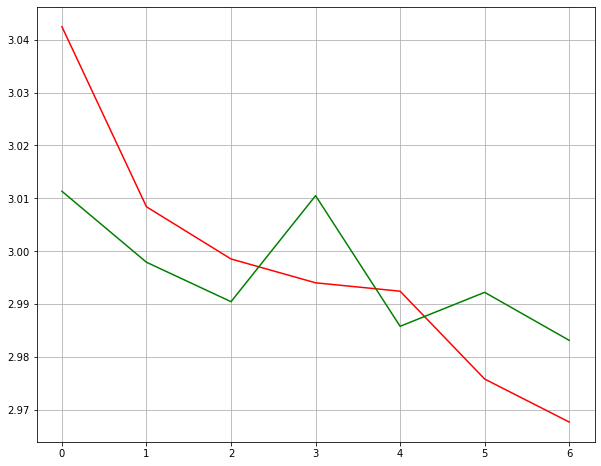

In [16]:
#model = MobileNetv2_DeepLabv3().to(device)
solver = Solver(class_weights = weights)
solver.train(model, train_dataloader, val_dataloader, num_epochs=7)

In [17]:
torch.save(model,"models/MobileNetv2_DeepLabv3_20.model") 

#### Changing resolution of generated BF gray images from pix2pixHD 

In [51]:
data = 'dataset_clean/testset/bf_gray_gan_10'
test_paths = get_all_files(data, 'jpg')

for i, path in enumerate(test_paths):
    im = Image.open(path)
    
    resized = im.resize((256, 256))
    gray = np.asarray(resized)
    path = path.replace('_synthesized_image.jpg','.png')
    plt.imsave(path, gray)                                     #(256,256,4)  # take only 1st dim(256,256,1)

### Testing Colorization model   (inp: BF gray, out: Bucket Taget indices for each pixel)

In [56]:


file_bf_test = open("bf_paths_test_10.txt", "w")  


for file in test_paths:
    file_bf_test.write( file + "\n")
    
file_bf_test.close()

from torch.autograd import Variable
test_data = ColorizationData(image_paths_file='bf_paths_test_10.txt',to_target_indices = ab_channels_to_bucket_target_indices)  
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

predictions = []
gt = []
model.eval()
for (inputs,targets) in test_dataloader:
                
    inputs, targets = Variable(inputs), Variable(targets)
                
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    
    
    _, preds = torch.max(outputs, 1)
    pred = preds[0].data.cpu()
    pred = pred.numpy()
    predictions.append(pred)
    
    gt.append((targets[0].data.cpu().numpy()))
model.train()
predictions = np.array(predictions) 
gt=np.array(gt)

In [57]:
predictions[1]

array([[175, 175, 175, ...,  97,  97,  97],
       [175, 175, 175, ...,  97,  97,  97],
       [175, 175, 175, ...,  97,  97,  97],
       ...,
       [ 98,  98,  98, ..., 194, 194, 194],
       [ 98,  98,  98, ..., 194, 194, 194],
       [ 98,  98,  98, ..., 194, 194, 194]])

In [58]:
gt[1]

array([[196, 175, 195, ...,  95,  95,  95],
       [195, 196, 196, ..., 114, 115, 115],
       [195, 195, 196, ..., 115,  95, 115],
       ...,
       [195, 174, 174, ..., 175, 196, 174],
       [174, 175, 175, ..., 195, 196, 154],
       [195, 195, 195, ..., 195, 175, 196]])

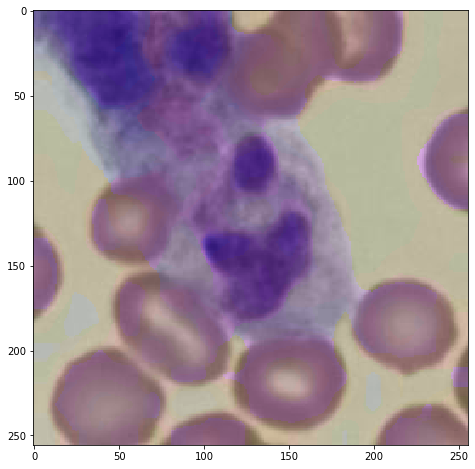

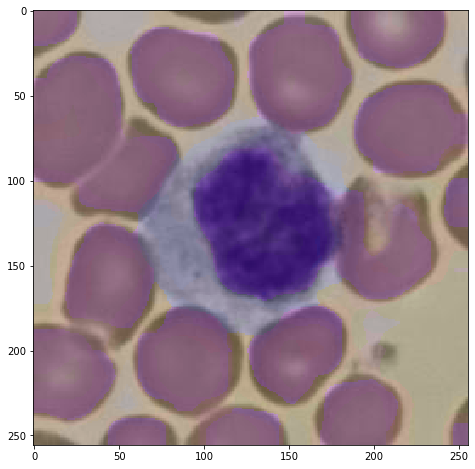

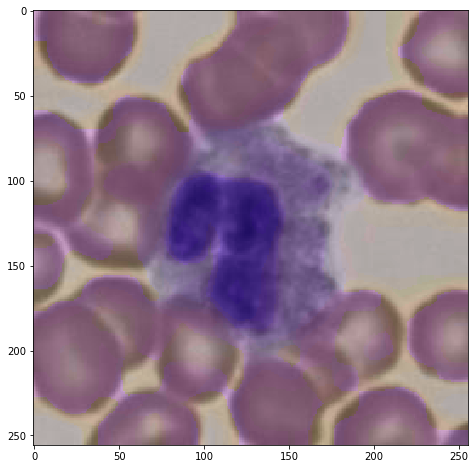

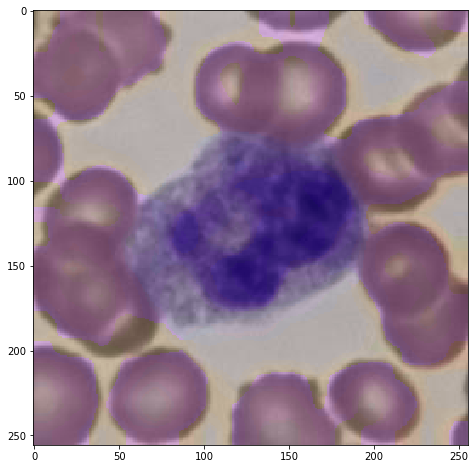

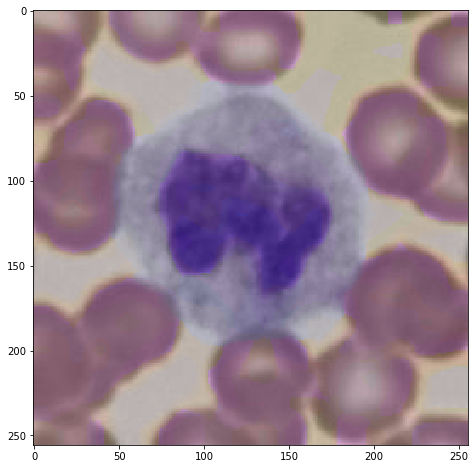

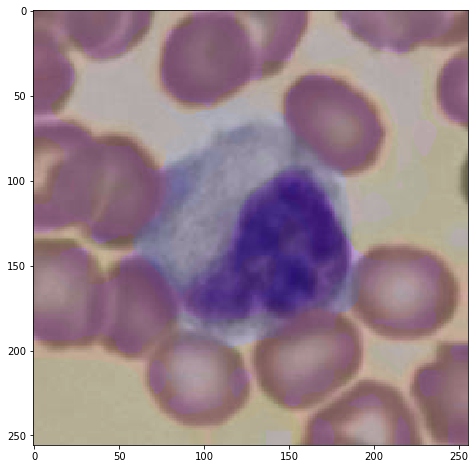

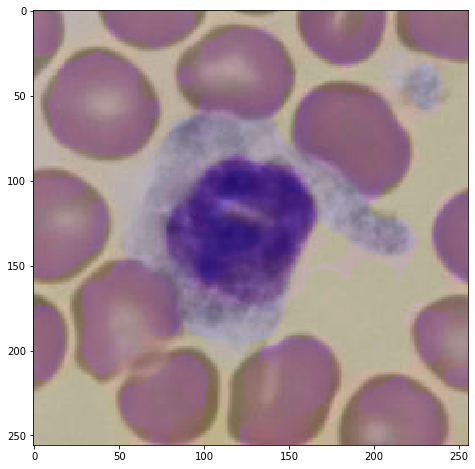

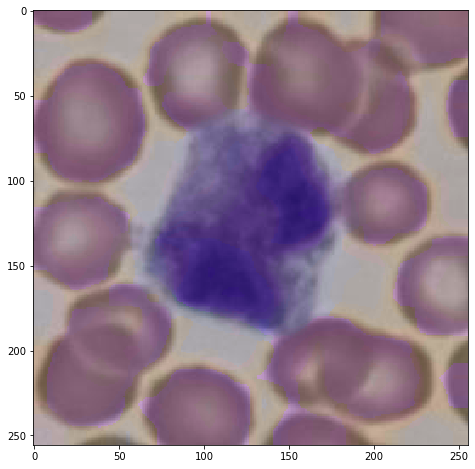

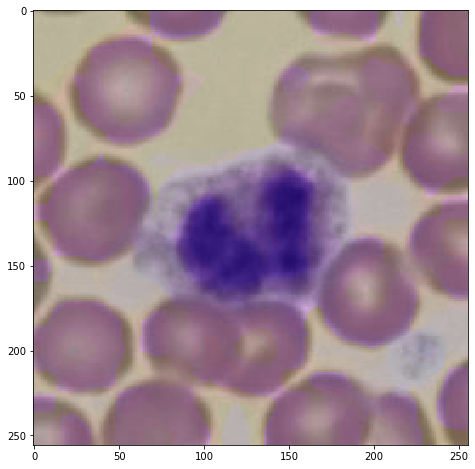

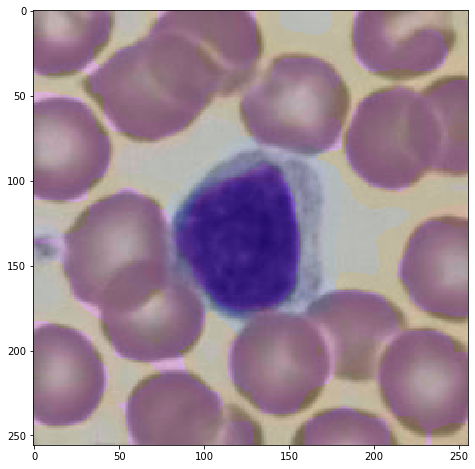

In [61]:
for i, path in enumerate(test_paths):
    im = Image.open(path)
    gray = np.asarray(im)
    lchannel = gray[np.newaxis,:,:,np.newaxis,0]*(100/255)
    pred = predictions[i]

    image_out_ab = bucket_target_indices_to_ab_channels(pred[np.newaxis,:,:])

    image_out = np.concatenate((lchannel, image_out_ab), axis=3)    # lab image

    rgb_image = lab2rgb(image_out[0])
    plt.figure()
    plt.imshow(rgb_image)
    path = path.replace('.png','result.png')
    plt.imsave(path,rgb_image)

### Quantization of ab space to buckets

In [ ]:
GRID_SIZE = 4                                                            #size = 16
NUM_TOTAL_BUCKETS = 4096                                                 #Total buckets = 256    -> 112 buckets in ab space
def get_bucket_id(ab_pixel):
    """ Given an ab coordinate, find the id of the bucket of
        that it belongs to.
        
        |ab_pixel|: np.array of shape (2,).
    """
    a = int(ab_pixel[0]) # floats cause a bug.
    b = int(ab_pixel[1])
    
    bucket_row = (a + 128) // GRID_SIZE
    bucket_col = (b + 128) // GRID_SIZE
    bucket_id = bucket_row * (256 // GRID_SIZE) + bucket_col
      
    return bucket_id

def discretize_ab_space():
    # initialize a blank array of (# buckets, 2).
    space = np.zeros(((256//GRID_SIZE)**2, 2))
    
    bucket_index = 0
    for a in range(-128, 128, GRID_SIZE):
        for b in range(-128, 128, GRID_SIZE):
            a_mid = float(a + GRID_SIZE / 2)
            b_mid = float(b + GRID_SIZE / 2)
            space[bucket_index] = a_mid, b_mid
            bucket_index += 1

    return space

def compute_bucket_maps(bucket2ab_map=None, ab2bucket_map=None):
    
    # If we have 228 buckets, the bucket at the 177th index could be bucket #210.
    # These maps keep track of the index in [0, 112) <-> the bucket id.
    global BUCKET_ID_TO_INDEX
    global BUCKET_INDEX_TO_ID
    
    # 1) Get our monte carlo ab color space.
    # Note: skimage.color's rgb2lab takes in RGB values normalized to [0,1].
    # Step sizes of 3 for R,G,B is granular enough for our purposes,
    #   in sampling RGB space.
    all_rgb_normed = [[r/255., g/255., b/255.] for r in range(0,256) \
                                               for g in range(0,256) \
                                               for b in range(0,256)]
    print("compute_bucket_maps(): finished getting all_rgb_normed")
    
    NUM_RGB_SAMPLES = len(all_rgb_normed)
    all_rgb_normed = np.array(all_rgb_normed)
    all_rgb_normed = all_rgb_normed[:, np.newaxis, :]        # shape (#rgb colors, 1, 3=rgb)
    assert all_rgb_normed.shape == (NUM_RGB_SAMPLES, 1, 3) #  new axis because skimage demands it.
    ab_colors = rgb2lab(all_rgb_normed)                    # (#rgb colors, 1, 3=lab)
    ab_colors = np.squeeze(ab_colors)[:,1:]                # (#rgb colors, 2=ab)
    assert ab_colors.shape == (NUM_RGB_SAMPLES, 2)
    
    # 2) Get our buckets. 
    # ab_buckets[bucket #] = (a,b) coord for that bucket, even if it isn't a valid RGB.
    ab_buckets_centers = discretize_ab_space()             # (#buckets, 2=ab)
    assert ab_buckets_centers.shape == (NUM_TOTAL_BUCKETS, 2)
    
    # 3) Now we calculate the closest bucket for each ab color.
    closest = [get_bucket_id(color) for color in ab_colors]
    valid_buckets = set(closest)
    
    # aside: for interpreting the softmax in the rainbowModel later, we need to know which neuron predicts which bucket
    BUCKET_ID_TO_INDEX = {bucket_id : i for i, bucket_id in enumerate(list(valid_buckets))}
    BUCKET_INDEX_TO_ID = {i : bucket_id for i, bucket_id in enumerate(list(valid_buckets))}
    print("bucket id to index ", BUCKET_ID_TO_INDEX)
    print("index to bucket id ", BUCKET_INDEX_TO_ID)
    
    # 4) Create the maps.
    bucket2ab_map = {bucket : tuple(ab_buckets_centers[bucket]) for bucket in valid_buckets}
    # Assert there are no repeats in the map
    assert len(bucket2ab_map.values()) == len(set(bucket2ab_map.values()))
    ab2bucket_map = {bucket2ab_map[bucket] : bucket for bucket in bucket2ab_map}
    assert len(ab2bucket_map.values()) == len(set(ab2bucket_map.values()))
    
    print ("There are %d final buckets." % len(bucket2ab_map))
    print ("There are %d final colors." % len(ab2bucket_map))
    
    return bucket2ab_map, ab2bucket_map

def plot_mapping(bucket2ab_map):
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    for bucket in bucket2ab_map:
        a_mid = bucket2ab_map[bucket][0]
        a_low = a_mid - GRID_SIZE / 2
        b_mid = bucket2ab_map[bucket][1]
        b_low = b_mid - GRID_SIZE / 2

        lab_pixel = np.array([50., a_mid, b_mid])
        lab_pixel = np.reshape(lab_pixel, (1, 1, 3))
        rgb = tuple(lab2rgb(lab_pixel)[0][0])

        ax.add_patch(
            patches.Rectangle(
                (b_low, -a_low), 
                GRID_SIZE, 
                GRID_SIZE, 
                facecolor=rgb
            )
        )

    plt.xlim([-128, 128])
    plt.ylim([-128, 128])
    plt.show()

In [3]:
bucket2ab_map, ab2bucket_map = compute_bucket_maps()
NUM_VALID_BUCKETS = len(bucket2ab_map)

compute_bucket_maps(): finished getting all_rgb_normed
bucket id to index  {691: 0, 692: 1, 751: 2, 752: 3, 753: 4, 754: 5, 755: 6, 756: 7, 811: 8, 812: 9, 813: 10, 814: 11, 815: 12, 816: 13, 817: 14, 818: 15, 819: 16, 820: 17, 821: 18, 873: 19, 874: 20, 875: 21, 876: 22, 877: 23, 878: 24, 879: 25, 880: 26, 881: 27, 882: 28, 883: 29, 884: 30, 885: 31, 934: 32, 935: 33, 936: 34, 937: 35, 938: 36, 939: 37, 940: 38, 941: 39, 942: 40, 943: 41, 944: 42, 945: 43, 946: 44, 947: 45, 948: 46, 949: 47, 996: 48, 997: 49, 998: 50, 999: 51, 1000: 52, 1001: 53, 1002: 54, 1003: 55, 1004: 56, 1005: 57, 1006: 58, 1007: 59, 1008: 60, 1009: 61, 1010: 62, 1011: 63, 1012: 64, 1013: 65, 1058: 66, 1059: 67, 1060: 68, 1061: 69, 1062: 70, 1063: 71, 1064: 72, 1065: 73, 1066: 74, 1067: 75, 1068: 76, 1069: 77, 1070: 78, 1071: 79, 1072: 80, 1073: 81, 1074: 82, 1075: 83, 1076: 84, 1077: 85, 1120: 86, 1121: 87, 1122: 88, 1123: 89, 1124: 90, 1125: 91, 1126: 92, 1127: 93, 1128: 94, 1129: 95, 1130: 96, 1131: 97, 1132: 

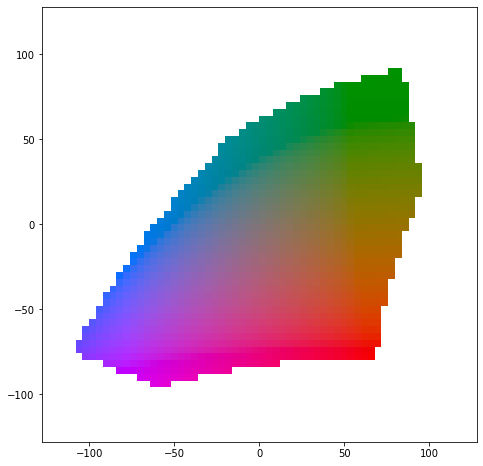

In [4]:
plot_mapping(bucket2ab_map)

## Main Functions that convert ab channels to target indices and vice-versa

In [5]:
def discretize(images_ab):
    """ This is a preprocessing step, that will be used in converting 
      Y (ab image true labels) into buckets, so that we can calculate
      a loss in colorization_loss().
  
      |images_ab|: (m, H, W, 2) array representing ab channels of images.
  
      :return: (m, H, W) array where each entry is in BUCKET_ID_TO_INDEX.
               One of the NUM_VALID_BUCKETS color buckets we found.
    """
    if len(images_ab.shape) == 3:
        print("discretize(): detected only 3 dims, reshaping to (m=1,:,:,:)")
        images_ab = images_ab[np.newaxis,:,:,:]
    
    assert BUCKET_ID_TO_INDEX is not None
  
    m, H, W, _ = images_ab.shape
    images_d = np.zeros((m, H, W))

    for i in range(m):
        for h in range(H):
            for w in range(W):
                ab_pixel = images_ab[i,h,w]
                bucket_id = get_bucket_id(ab_pixel)
                index = BUCKET_ID_TO_INDEX[bucket_id] # int in range [0, Num_Valid_Buckets)
                images_d[i,h,w] = BUCKET_INDEX_TO_TARGET_INDEX[index]
                #images_d[i,h,w] = BUCKET_ID_TO_INDEX[bucket_id]
    return images_d.astype('int32')

# New name!
# ---------
ab_channels_to_bucket_target_indices = discretize

# This function will be called when we want to demo a predicted image.
# It takes an image with pixels labeled with buckets, and transforms it
#   into 2 color channels.

def inverse_discretize(images_d):
    """ The inverse of the above function. Maps the indicated bucket to
      the mean of that bucket.
      
      |images_d|: an array (m,H,W) with the color bucket *index=logit* 
                  assigned to each pixel.
                  
     :return: (m, H, W, 2) array with ab color values.
    """
    if len(images_d.shape) == 2:
        print("inverse_discretize(): detected only 2 dims, reshaping to (m=1,:,:)")
        images_d = images_d[np.newaxis,:,:]

    m, H, W = images_d.shape
    images_ab = np.zeros((m, H, W, 2))
  
    for i in range(m):
        for h in range(H):
            for w in range(W):
                target_index = images_d[i,h,w]
                bucket_index = BUCKET_TARGET_INDEX_TO_INDEX[target_index]
                bucket_id = BUCKET_INDEX_TO_ID[bucket_index]
                #bucket_id = BUCKET_INDEX_TO_ID[target_index]
                images_ab[i,h,w] = bucket2ab_map[bucket_id] # Sets to [a,b]
  
    return images_ab

# New name!
# ---------
bucket_target_indices_to_ab_channels = inverse_discretize

### Remapping, so that the bucket target indices are continuous

In [8]:
global BUCKET_INDEX_TO_TARGET_INDEX
global BUCKET_TARGET_INDEX_TO_INDEX

needed_indices =[]
for path in train_bf_paths:
    img = Image.open(path)             # PIL image
    img = np.asarray(img)
    images = rgb2lab(img)
    images = images[np.newaxis,:,:,:]                 #(1,256,256,3)

    #channel = images[:,:,:,0,np.newaxis]
    images_ab = images[:,:,:,1:]

    images_d = ab_channels_to_bucket_target_indices(images_ab)
    #print(images_d)
    needed_indices.extend(list(np.unique(images_d)))
    
needed_indices = sorted(set(needed_indices)) 
print(needed_indices)
BUCKET_INDEX_TO_TARGET_INDEX = {index_id : i for i, index_id in enumerate(list(needed_indices))}
BUCKET_TARGET_INDEX_TO_INDEX = {i : index_id for i, index_id in enumerate(list(needed_indices))}
print(BUCKET_INDEX_TO_TARGET_INDEX)
print(BUCKET_TARGET_INDEX_TO_INDEX)

[319, 349, 350, 352, 354, 382, 383, 384, 385, 386, 387, 388, 391, 392, 394, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 634, 635, 636, 637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 647, 648, 649, 650, 651, 652, 653, 671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764,

In [6]:
#np.save('BUCKET_INDEX_TO_TARGET_INDEX.npy', BUCKET_INDEX_TO_TARGET_INDEX) 
#np.save('BUCKET_TARGET_INDEX_TO_INDEX.npy', BUCKET_TARGET_INDEX_TO_INDEX) 
# Load
BUCKET_INDEX_TO_TARGET_INDEX = np.load('BUCKET_INDEX_TO_TARGET_INDEX.npy',allow_pickle='TRUE').item()
BUCKET_TARGET_INDEX_TO_INDEX = np.load('BUCKET_TARGET_INDEX_TO_INDEX.npy',allow_pickle='TRUE').item()

### Visualization RGB actual image and RGB-LAB-RGB converted image

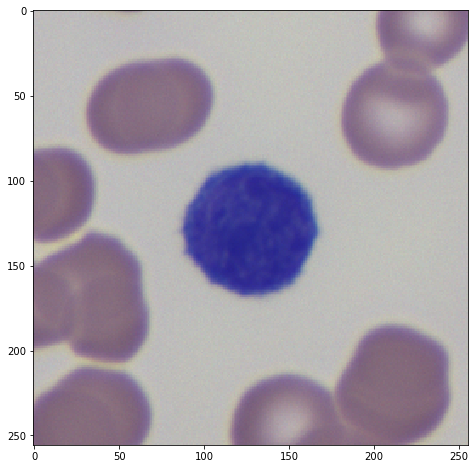

In [8]:
data = 'dataset_clean/testset/bf'
test_bf_paths = get_all_files(data, 'png')
im =Image.open(test_bf_paths[129])
a=np.asarray(im)
plt.imshow(a)

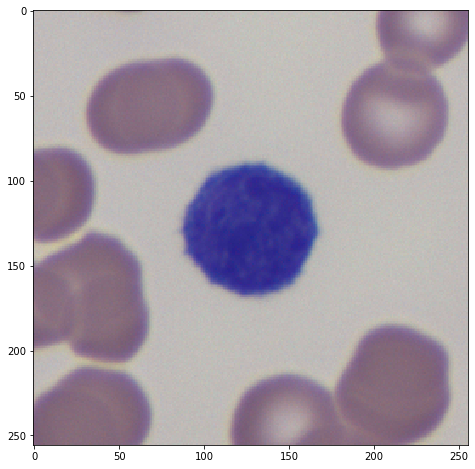

In [9]:

images = rgb2lab(a)
images = images[np.newaxis,:,:,:]                 #(1,256,256,3)

lchannel = images[:,:,:,0,np.newaxis]
images_ab = images[:,:,:,1:]

images_d = ab_channels_to_bucket_target_indices(images_ab)
#print(images_d)
images_out_ab = bucket_target_indices_to_ab_channels(images_d)
#print(images_out_ab)
#print(images_out_ab.shape)
images_out = np.concatenate((lchannel, images_out_ab), axis=3)

rgb_images = lab2rgb(images_out[0])
plt.figure()
plt.imshow(rgb_images)